<a href="https://colab.research.google.com/github/FarjanaAkterLaila/Advanced_Sarcasm_Detection-_and-_Analyzing_Formal-Informal_Languages_using_Transformed-Based-Models/blob/main/For_Formal_Language__using__Roberta_Distilbert_Albert_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data


In [ ]:
import pandas as pd
df = pd.read_csv("/content/formal-dataset.csv",encoding='latin-1')
df.head()

,headline,is_sarcastic
0,former versace store clerk sues over secret 'b...,0
1,The revival of 'Roseanne' reflects the complex...,0
2,A mother expresses concern that her son's web ...,1
3,Boehner desires his wife to listen rather than...,1
4,J.K. Rowling commemorates Snape's birthday in ...,0


In [ ]:
len(df['headline'].values)

10003

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import re
import nltk
from nltk import word_tokenize
import numpy as np

In [ ]:
import re  # Import the 're' module for regular expressions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# 2. Text Cleaning Function (with URL handling)
def clean_text(text):
    # Convert the input to a string if it is not already.
    if not isinstance(text, str):
        text = str(text)

    text = re.sub(r"http\S+|www\S+|https\S+", " [LINK] ", text, flags=re.MULTILINE)

    text = re.sub('[^a-zA-Z]', ' ', text).lower()

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
print(clean_text(df['headline'][0]))

former versace store clerk sues over secret black code for minority shoppers


In [ ]:
df['cleaned_headlines'] = df['headline'].apply(lambda x: clean_text(x))

In [ ]:
df.shape

(10003, 3)

In [ ]:
# reduced_sarcasm_df = df.head(10000)

In [ ]:
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,5515
1,4488


In [ ]:
# Check for missing values in the DataFrame, not the list
print('missing value for formal dataset :' ,df['headline'].isnull().sum())

# # Remove duplicates if any, directly from the DataFrame
# df.drop_duplicates(subset=['headline'], inplace=True)
duplicates = df['headline'].duplicated().sum()
print(f"Number of duplicate headlines: {duplicates}")



missing value for formal dataset : 0
Number of duplicate headlines: 23


In [ ]:
# Find duplicated headlines and display them
duplicated_texts = df[df['headline'].duplicated(keep=False)]['headline']

# Display the duplicated texts
print("Duplicated headlines:")
for i, text in enumerate(duplicated_texts.unique(), 1):
    print(f"{i}. {text}")

Duplicated headlines:
1. antarctic observational comic running out of ideas
2. sunday roundup
3. No One Can Match DC Pandas Enthusiasm for Snow
4. goliath opens his wallet: a new era for cuba and the united states
5. watch one of the world's largest lakes shrink before your eyes
6. 12 stunning photos of 'tiny dancers' caught in action
7. private vehicles beat ambulances in saving gunshot and stabbing victims
8. living in the moment: the beauty of uncertainty
9. 5 heroes who need your help amid aleppo crisis
10. vice gearing up for nightly hbo show with new hires, moves
11. white house talks tough on iran, but suggests nuke deal is ok after all
12. despite madaya aid, u.n. still fails to end country's sieges
13. after decades of effort, chemists overseas report 'nano' breakthrough
14. joe biden berates white house over 'joke' about john mccain's health
15. American universities are establishing Sino-foreign joint education ventures in China
16. heartbreaking illustrations document the 

In [ ]:
df.drop_duplicates(subset=['headline'], inplace=True)

In [ ]:
len(df['headline'].values)

9980

In [ ]:
df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,5494
1,4486


### labeling

In [ ]:
from imblearn.over_sampling import RandomOverSampler

def balance_df(df, text, target):
    ros = RandomOverSampler()
    train_x, train_y = ros.fit_resample(np.array(df[text]).reshape(-1,1), np.array(df[target]).reshape(-1,1))
    new_df = pd.DataFrame(list(zip([x[0] for x in train_x], train_y)), columns = [text, target])

    return new_df


sarcasm_df = pd.DataFrame()
sarcasm_df = balance_df(df, 'cleaned_headlines', 'is_sarcastic')

In [ ]:
print(sarcasm_df['cleaned_headlines'][0])

former versace store clerk sues over secret black code for minority shoppers


In [ ]:
sarcasm_df.head()

,cleaned_headlines,is_sarcastic
0,former versace store clerk sues over secret bl...,0
1,the revival of roseanne reflects the complex p...,0
2,a mother expresses concern that her son s web ...,1
3,boehner desires his wife to listen rather than...,1
4,j k rowling commemorates snape s birthday in a...,0


In [ ]:
sarcasm_df['is_sarcastic'].value_counts()

,count
is_sarcastic,
0,5494
1,5494


### Split Data

In [ ]:
X = sarcasm_df["cleaned_headlines"]
y = sarcasm_df['is_sarcastic']

# X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

# Split data into train, validation, and test sets
train_texts, val_texts, train_labels, val_labels = train_test_split(
    X, y, test_size=0.20, random_state=42
)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    train_texts, train_labels, test_size=0.20, random_state=42
)

In [ ]:
train_texts.shape, val_texts.shape, train_labels.shape, val_labels.shape,test_texts.shape, test_labels.shape

((7032,), (2198,), (7032,), (2198,), (1758,), (1758,))

## Roberta model

In [ ]:
from transformers import RobertaTokenizer, TFRobertaForSequenceClassification

# Load tokenizer and model
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model= TFRobertaForSequenceClassification.from_pretrained('roberta-base')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

In [ ]:
max_length = max(len(text) for text in df['cleaned_headlines'])
max_length

187

In [ ]:
train_encodings = tokenizer(train_texts.tolist(), padding=True, truncation=True, max_length=max_length)
# train_encodings = tokenizer(X_train.tolist(), padding=True, truncation=True, max_length=max_length)
train_encodings

{'input_ids': [[0, 9579, 7058, 14755, 7, 26088, 42, 983, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 34996, 7441, 1383, 15520, 122, 66, 30695, 2360, 7, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 627, 1717, 579, 866, 2092, 7, 28, 18060, 13, 2003, 2990, 6168, 2583, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 627, 1984, 9731, 7, 15311, 49, 5254, 9, 8222, 8315, 25, 41, 9280, 7, 14095, 5, 11012, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 8015, 2426, 579, 4047, 415, 9762, 19, 7564, 44355, 1610, 337, 14372, 11, 5386, 2734, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 642, 763, 36181, 2335, 14294, 122, 490, 13, 265, 709, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0, 1584, 5954, 32, 7664, 40165, 7, 28701, 12953, 390, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 

In [ ]:
val_encodings = tokenizer(val_texts.tolist(), padding=True, truncation=True, max_length=max_length)
# test_encodings = tokenizer(X_test.tolist(), padding=True, truncation=True, max_length=max_length)

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), train_labels))
val_dataset= tf.data.Dataset.from_tensor_slices((dict(val_encodings), val_labels))
# train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train))
# test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test))
train_dataset

<_TensorSliceDataset element_spec=({'input_ids': TensorSpec(shape=(37,), dtype=tf.int32, name=None), 'attention_mask': TensorSpec(shape=(37,), dtype=tf.int32, name=None)}, TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
# max_length=130

In [ ]:
# Define custom model architecture
input_ids = tf.keras.Input(shape=(None,), dtype=tf.int32, name='input_ids')
attention_mask = tf.keras.Input(shape=(None,), dtype=tf.int32, name='attention_mask')

# RoBERTa output
roberta_output = model(input_ids, attention_mask=attention_mask)
logits = roberta_output.logits

# Add custom dense layers
x = tf.keras.layers.Dense(256, activation='relu')(logits)
x = tf.keras.layers.Dropout(0.3)(x)  # Dropout layer for regularization
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)  # Dropout layer for regularization

# Output layer with two units for binary classification
output = tf.keras.layers.Dense(2, activation='softmax')(x)

# Create the model
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)

# Compile the model with optimizer and loss function
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)  # Adjust the learning rate for fine-tuning
loss = tf.keras.losses.SparseCategoricalCrossentropy()
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

# Display the model summary
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_roberta_for_sequence_cl  TFSequenceClassifierOutput   1246471   ['input_ids[0][0]',           
 assification (TFRobertaFor  (loss=None, logits=(None,    70         'attention_mask[0][0]']      
 SequenceClassification)     2),                                                              

In [ ]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
# loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [ ]:
# test_encodings = tokenizer(
#     X_test.tolist(),
#     padding=True,
#     truncation=True,
#     max_length=max_length  # Use the correct max_length here
# )

In [ ]:
history = model.fit(
    train_dataset.shuffle(1000).batch(16),
    epochs=4,
    batch_size=8,
    validation_data=val_dataset.batch(16)
    # validation_data=test_dataset.batch(16)
)


Epoch 1/4
440/440 [==============================] - 129s 203ms/step - loss: 0.5261 - accuracy: 0.7359 - val_loss: 0.3269 - val_accuracy: 0.8608
Epoch 2/4
440/440 [==============================] - 76s 172ms/step - loss: 0.2960 - accuracy: 0.8896 - val_loss: 0.2982 - val_accuracy: 0.8858
Epoch 3/4
440/440 [==============================] - 74s 168ms/step - loss: 0.1886 - accuracy: 0.9389 - val_loss: 0.3189 - val_accuracy: 0.8844
Epoch 4/4
440/440 [==============================] - 74s 169ms/step - loss: 0.1264 - accuracy: 0.9600 - val_loss: 0.3807 - val_accuracy: 0.8954


In [ ]:
# model.summary()

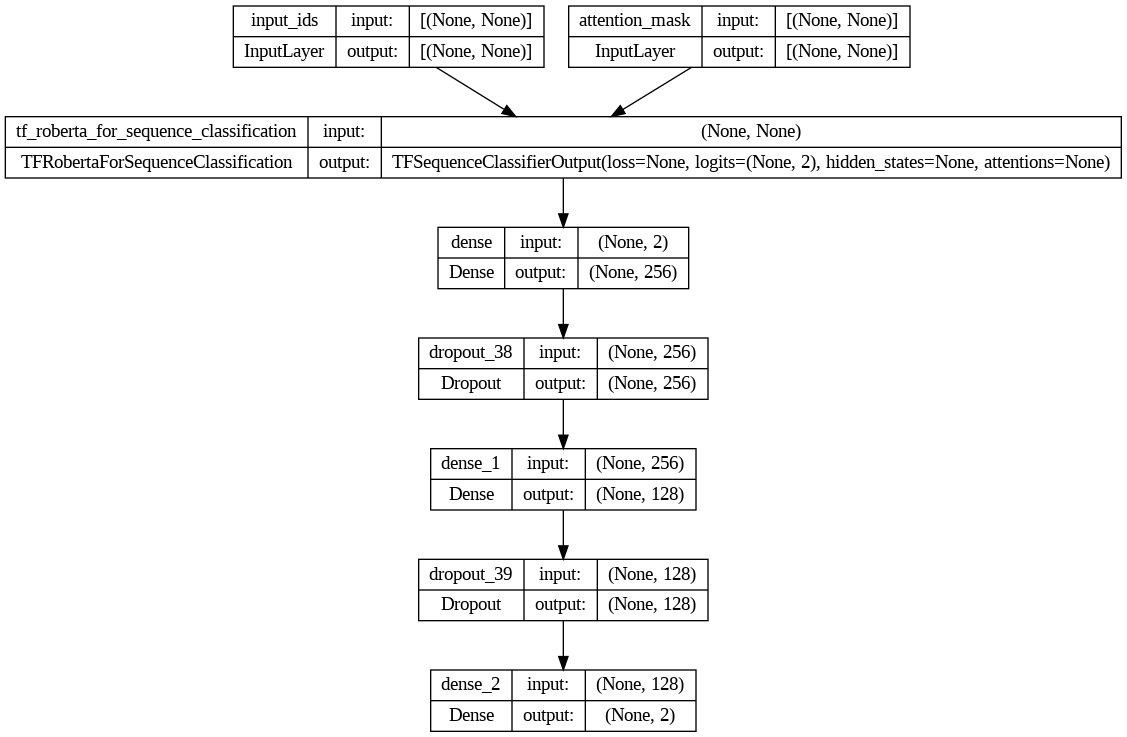

In [ ]:
from tensorflow import keras
keras.utils.plot_model(model, to_file='Roberta model.png', show_shapes=True)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
# Make predictions and evaluate
val_preds = model.predict(val_dataset.batch(16))
val_preds = tf.argmax(val_preds, axis=1).numpy()   # Get predicted class labels
print("Validation Classification Report:")
print(classification_report(val_labels, val_preds))

# Tokenize and prepare test set
test_encodings = tokenizer(test_texts.to_list(), truncation=True, padding=True, max_length=512)
test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels
))

# Evaluate on test set
test_preds = model.predict(test_dataset.batch(16))
test_preds = tf.argmax(test_preds, axis=1).numpy()  # Get predicted class labels
print("Test Classification Report:")
print(classification_report(test_labels, test_preds))

# Calculate and print accuracy
val_accuracy = accuracy_score(val_labels, val_preds)
test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


138/138 [==============================] - 12s 70ms/step
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1077
           1       0.89      0.91      0.90      1121

    accuracy                           0.90      2198
   macro avg       0.90      0.90      0.90      2198
weighted avg       0.90      0.90      0.90      2198

110/110 [==============================] - 9s 54ms/step
Test Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       874
           1       0.89      0.90      0.89       884

    accuracy                           0.89      1758
   macro avg       0.89      0.89      0.89      1758
weighted avg       0.89      0.89      0.89      1758

Validation Accuracy: 0.8954
Test Accuracy: 0.8908


In [ ]:
# y_probs = model.predict(test_dataset.batch(16))
# y_pred = np.argmax(y_probs, axis=1)

In [ ]:

# model_evaluation_history = model.evaluate(test_dataset.batch(16))

# print(model_evaluation_history)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

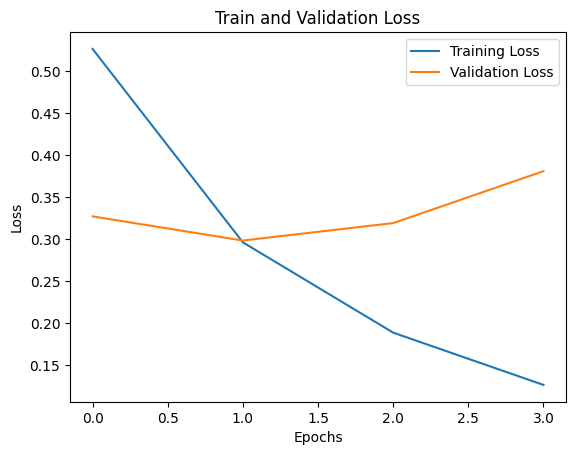

In [ ]:
# Assuming history contains the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Train and Validation Loss")
plt.legend()  # This will show the legend based on the labels specified above
plt.show()

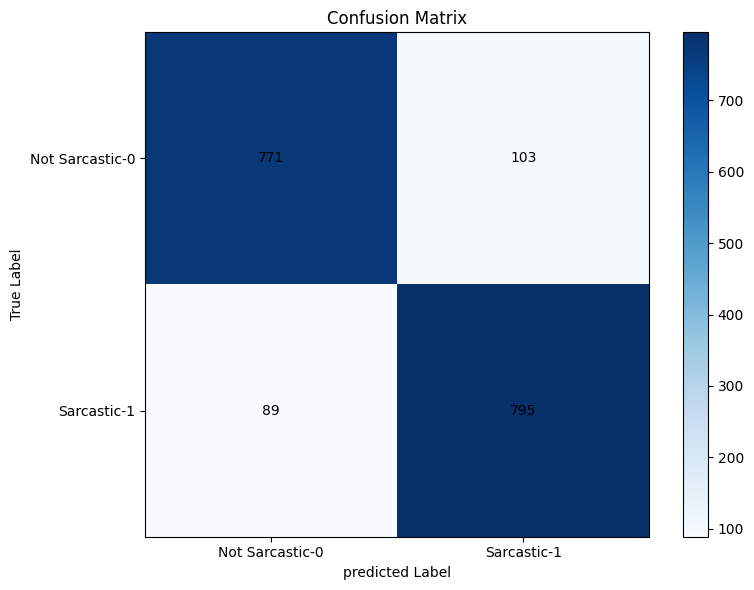

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming 'test_labels' and 'test_preds' are your true and predicted labels for the test set
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])
plt.yticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.xlabel("predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(8,6))
# plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
# plt.title("Confusion Matrix")
# plt.colorbar()
# tick_marks = np.arange(2)
# plt.xticks(tick_marks, ['Nor Sarcastic', 'Sarcastic'])
# plt.yticks(tick_marks, ['Nor Sarcastic', 'Sarcastic'])

# thresh = cm.max() / 2.
# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

# plt.xlabel("predicted Label")
# plt.ylabel("True Label")
# plt.tight_layout()
# plt.show()

In [ ]:
# accuracy = classification_report(y_test, y_pred)
# print(accuracy)

In [ ]:
# # test_preds = model.predict(test_texts)
# # Create a DataFrame with true and predicted labels
# predictions_df = pd.DataFrame({'True_Label': y_test, 'Predicted_Label': y_pred , 'Text': X_test})

# # Display the table
# display(predictions_df[:50])
# Create a DataFrame with true and predicted labels
predictions_df = pd.DataFrame({'True_Label': test_labels, 'Predicted_Label': test_preds, 'Text': test_texts})

# Display the table
display(predictions_df[:50])

,True_Label,Predicted_Label,Text
5708,0,0,this job at netflix is an instagrammer s dream
512,1,1,nasa completely forgot probe was returning today
6759,0,1,the cat observes an unexpected visitor at the ...
4595,0,0,effective pr on a start up budget
10164,1,1,the public is assured that the escaped convict...
9513,1,1,family graciously invites cars inside the hous...
5924,0,0,monday s morning email what the global cyberat...
8372,0,0,fishermen hook massive great whites off carolinas
4499,0,0,bangladesh bloggers fear deadly backlash won t...
1725,0,0,a man attempted to eliminate a spider with a l...


### validation- ROC-AUC Cruve

In [ ]:
# Validation dataset
val_probs = model.predict(val_dataset.batch(16))  # Validation predictions as logits
val_probs = tf.nn.softmax(val_probs).numpy()  # Convert logits to probabilities using softmax
val_preds = tf.argmax(val_probs, axis=1).numpy()  # Convert probabilities to class predictions
# Test dataset
test_probs = model.predict(test_dataset.batch(16))  # Test predictions as logits
test_probs = tf.nn.softmax(test_probs).numpy()  # Convert logits to probabilities using softmax
test_preds = tf.argmax(test_probs, axis=1).numpy()  # Convert probabilities to class predictions

110/110 [==============================] - 6s 51ms/step


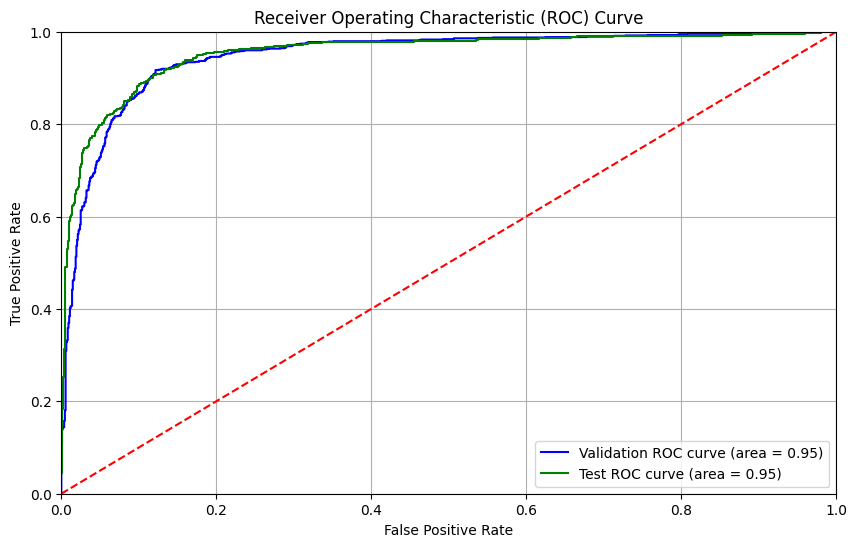

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming val_probs contains the predicted probabilities for the positive class from the validation set
# and val_labels contains the true labels for the validation set.
val_probs = val_probs[:, 1]  # Replace with your actual validation probabilities
val_labels = val_labels  # True labels for validation

# Assuming test_probs contains the predicted probabilities for the positive class from the test set
# and test_labels contains the true labels for the test set.
test_probs = test_probs[:, 1]  # Replace with your actual test probabilities
test_labels = test_labels  # True labels for test

# Compute ROC curve and AUC for validation set
fpr_val, tpr_val, _ = roc_curve(val_labels, val_probs)
roc_auc_val = auc(fpr_val, tpr_val)

# Compute ROC curve and AUC for test set
fpr_test, tpr_test, _ = roc_curve(test_labels, test_probs)
roc_auc_test = auc(fpr_test, tpr_test)

# Plotting both ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', label='Validation ROC curve (area = {:.2f})'.format(roc_auc_val))
plt.plot(fpr_test, tpr_test, color='green', label='Test ROC curve (area = {:.2f})'.format(roc_auc_test))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


### Validation-log-loss,Matthews Correlation Coefficient (MCC), Cohen's Kappa Score,Brier Score

In [ ]:
import tensorflow as tf
from sklearn.metrics import log_loss, matthews_corrcoef, cohen_kappa_score, brier_score_loss

# Validation Metrics
val_loss = log_loss(val_labels, val_probs)  # Assuming val_probs is 1D
val_mcc = matthews_corrcoef(val_labels, val_preds)
val_kappa = cohen_kappa_score(val_labels, val_preds)
val_brier = brier_score_loss(val_labels, val_probs)  # Use val_probs directly

print(f"Validation Log Loss: {val_loss:.4f}")
print(f"Validation MCC: {val_mcc:.4f}")
print(f"Validation Cohen's Kappa Score: {val_kappa:.4f}")
print(f"Validation Brier Score: {val_brier:.4f}")

# Test Metrics
test_loss = log_loss(test_labels, test_probs)  # Assuming test_probs is 1D
test_mcc = matthews_corrcoef(test_labels, test_preds)
test_kappa = cohen_kappa_score(test_labels, test_preds)
test_brier = brier_score_loss(test_labels, test_probs)  # Use test_probs directly

print(f"Test Log Loss: {test_loss:.4f}")
print(f"Test MCC: {test_mcc:.4f}")
print(f"Test Cohen's Kappa Score: {test_kappa:.4f}")
print(f"Test Brier Score: {test_brier:.4f}")


Validation Log Loss: 0.4199
Validation MCC: 0.7908
Validation Cohen's Kappa Score: 0.7905
Validation Brier Score: 0.1215
Test Log Loss: 0.4178
Test MCC: 0.7816
Test Cohen's Kappa Score: 0.7815
Test Brier Score: 0.1207


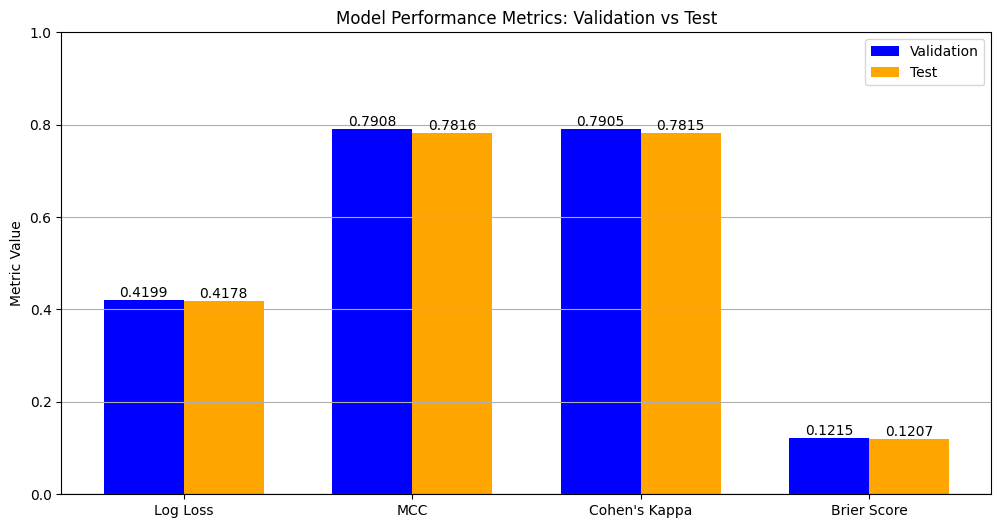

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define metrics and their values for validation and test sets
metrics = ['Log Loss', 'MCC', "Cohen's Kappa", 'Brier Score']

# Replace these with your actual computed metric values for validation and test
val_values = [val_loss, val_mcc, val_kappa, val_brier]  # Validation metrics
test_values = [test_loss, test_mcc, test_kappa, test_brier]  # Test metrics

# Set bar width
bar_width = 0.35

# Create bar plot
x = np.arange(len(metrics))  # the label locations

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, val_values, bar_width, label='Validation', color='blue')
bars2 = plt.bar(x + bar_width/2, test_values, bar_width, label='Test', color='orange')

# Add labels and title
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics: Validation vs Test')
plt.xticks(x, metrics)  # Set x-ticks to metrics names
plt.legend()  # Show legend

# Show value on top of each bar
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Adjust y-axis limit if necessary
plt.axhline(0, color='black', linewidth=0.8)  # Optional: horizontal line at y=0
plt.grid(axis='y')  # Add gridlines for better readability
plt.show()


# Albert

In [ ]:
from transformers import AlbertTokenizer, TFAlbertModel
# Load ALBERT tokenizer and model
tokenizer = AlbertTokenizer.from_pretrained('albert-base-v2')
albert_model = TFAlbertModel.from_pretrained('albert-base-v2')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFAlbertModel: ['predictions.LayerNorm.weight', 'predictions.dense.bias', 'predictions.decoder.bias', 'predictions.LayerNorm.bias', 'predictions.bias', 'predictions.dense.weight']
- This IS expected if you are initializing TFAlbertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFAlbertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFAlbertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFAlbertModel for predictions without further training.


In [ ]:
# Tokenize the data
train_encodings = tokenizer(train_texts.tolist(), padding=True, truncation=True, max_length=512)
val_encodings = tokenizer(val_texts.tolist(), padding=True, truncation=True, max_length=512)
# train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=512)
# test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=512)

In [ ]:
train_encodings

{'input_ids': [[2, 355, 11398, 8419, 18, 20, 23804, 48, 4010, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 2732, 171, 22234, 7886, 26, 2152, 9992, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 14, 287, 13, 18, 3038, 1780, 20, 44, 23411, 26, 15849, 7677, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 7095, 18102, 11940, 5636, 27, 156, 2570, 16, 51, 582, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 740, 13, 18, 19, 1473, 2473, 857, 29, 13, 1326, 1324, 863, 192, 16814, 19, 6153, 3161, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 10918, 1952, 5459, 130, 368, 26, 508, 522, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2, 17247, 103, 8790, 2999, 8740, 84, 14, 5315, 16, 21, 1823, 1381, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [2,

In [ ]:
# # Convert encodings to TensorFlow datasets
# train_dataset = tf.data.Dataset.from_tensor_slices((
#     dict(train_encodings),
#      y_train
# ))
# test_dataset = tf.data.Dataset.from_tensor_slices((
#     dict(test_encodings),
#      y_test
# ))
# Convert encodings to TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings),train_labels))
val_dataset= tf.data.Dataset.from_tensor_slices((dict(val_encodings), val_labels))

In [ ]:
train_dataset

<_TensorSliceDataset element_spec=({'input_ids': TensorSpec(shape=(38,), dtype=tf.int32, name=None), 'token_type_ids': TensorSpec(shape=(38,), dtype=tf.int32, name=None), 'attention_mask': TensorSpec(shape=(38,), dtype=tf.int32, name=None)}, TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
# Define input layers for the ALBERT model
input_ids = tf.keras.Input(shape=(None,), dtype=tf.int32, name='input_ids')
attention_mask = tf.keras.Input(shape=(None,), dtype=tf.int32, name='attention_mask')

In [ ]:


# Get the hidden states from ALBERT
hidden_states = albert_model(input_ids, attention_mask=attention_mask).last_hidden_state

# Extract the [CLS] token representation
cls_token = hidden_states[:, 0, :]

# Custom dense and dropout layers
pooled_dense = tf.keras.layers.Dense(768, activation='relu', name='pooled_dense')(cls_token)
output_dropout = tf.keras.layers.Dropout(0.1, name='output_dropout')(pooled_dense)
logits = tf.keras.layers.Dense(2, name='logits')(output_dropout)

# Define the complete model
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=logits)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5, epsilon=1e-08)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])



In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_albert_model (TFAlbertM  TFBaseModelOutputWithPooli   1168358   ['input_ids[0][0]',           
 odel)                       ng(last_hidden_state=(None   4          'attention_mask[0][0]']      
                             , None, 768),                                                    

In [ ]:
# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(
    train_dataset.shuffle(1000).batch(16),
    epochs=4,
    batch_size=16,
    validation_data=val_dataset.shuffle(1000).batch(16),
    callbacks=[early_stopping]
)

Epoch 1/4


/usr/local/lib/python3.10/dist-packages/tf_keras/src/engine/functional.py:641: UserWarning: Input dict contained keys ['token_type_ids'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


440/440 [==============================] - 90s 159ms/step - loss: 0.5083 - accuracy: 0.7490 - val_loss: 0.3804 - val_accuracy: 0.8403
Epoch 2/4
440/440 [==============================] - 65s 148ms/step - loss: 0.3087 - accuracy: 0.8734 - val_loss: 0.3594 - val_accuracy: 0.8430
Epoch 3/4
440/440 [==============================] - 65s 147ms/step - loss: 0.1886 - accuracy: 0.9303 - val_loss: 0.4897 - val_accuracy: 0.8217
Epoch 4/4
440/440 [==============================] - 67s 153ms/step - loss: 0.1087 - accuracy: 0.9615 - val_loss: 0.4576 - val_accuracy: 0.8640


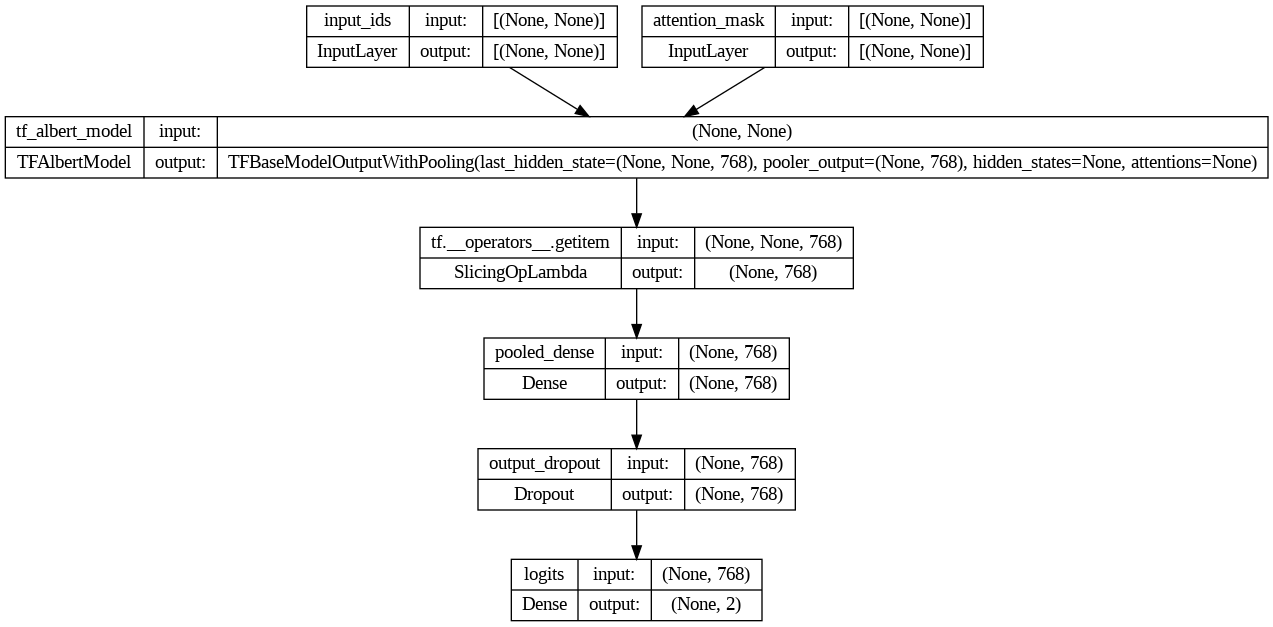

In [ ]:
from tensorflow import keras
keras.utils.plot_model(model, to_file='Albert model.png', show_shapes=True)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
# Make predictions and evaluate
val_preds = model.predict(val_dataset.batch(16))
val_preds = tf.argmax(val_preds, axis=1).numpy()   # Get predicted class labels
print("Validation Classification Report:")
print(classification_report(val_labels, val_preds))

# Tokenize and prepare test set
test_encodings = tokenizer(test_texts.to_list(), truncation=True, padding=True, max_length=512)
test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels
))

# Evaluate on test set
test_preds = model.predict(test_dataset.batch(16))
test_preds = tf.argmax(test_preds, axis=1).numpy()  # Get predicted class labels
print("Test Classification Report:")
print(classification_report(test_labels, test_preds))

# Calculate and print accuracy
val_accuracy = accuracy_score(val_labels, val_preds)
test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


138/138 [==============================] - 11s 60ms/step
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1077
           1       0.88      0.80      0.84      1121

    accuracy                           0.84      2198
   macro avg       0.85      0.84      0.84      2198
weighted avg       0.85      0.84      0.84      2198



/usr/local/lib/python3.10/dist-packages/tf_keras/src/engine/functional.py:641: UserWarning: Input dict contained keys ['token_type_ids'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


110/110 [==============================] - 8s 52ms/step
Test Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       874
           1       0.88      0.80      0.84       884

    accuracy                           0.85      1758
   macro avg       0.85      0.85      0.85      1758
weighted avg       0.85      0.85      0.85      1758

Validation Accuracy: 0.8430
Test Accuracy: 0.8464


In [ ]:
# y_probs = model.predict(test_dataset.batch(16))
# y_pred = np.argmax(y_probs, axis=1)

In [ ]:
# model_evaluation_history = model.evaluate(test_dataset.batch(16))

# print(model_evaluation_history)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
# accuracy = classification_report(y_test, y_pred)
# print(accuracy)

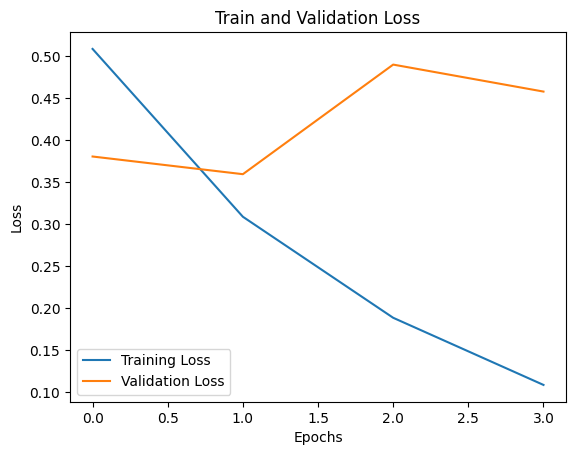

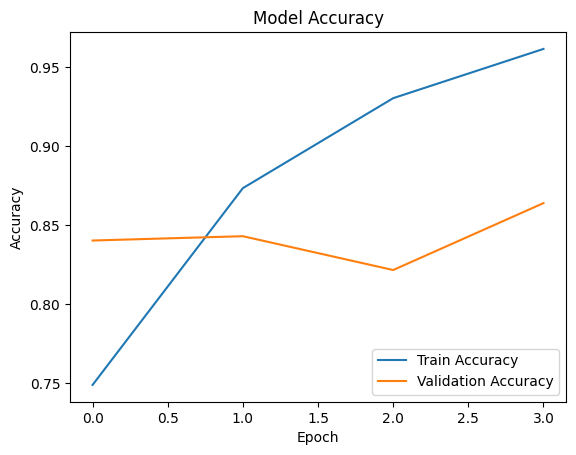

In [ ]:
# Assuming history contains the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Train and Validation Loss")
plt.legend()  # This will show the legend based on the labels specified above
plt.show()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# plt.plot(history.history['accuracy'], label='Train Accuracy')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
# plt.title('Model Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend(loc='lower right')
# plt.show()

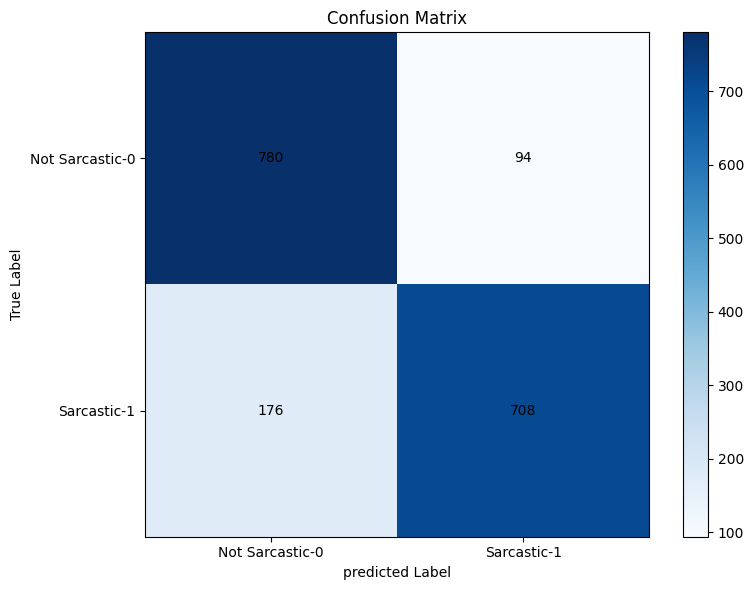

In [ ]:
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(8,6))
# plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
# plt.title("Confusion Matrix")
# plt.colorbar()
# tick_marks = np.arange(2)
# plt.xticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])
# plt.yticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])

# thresh = cm.max() / 2.
# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

# plt.xlabel("predicted Label")
# plt.ylabel("True Label")
# plt.tight_layout()
# plt.show()


cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])
plt.yticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.xlabel("predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [ ]:
# Show token IDs and the corresponding tokens for the first few examples
for i in range(5):
    print(f"Example {i + 1}:")
    print(f"Token IDs: {train_encodings['input_ids'][i]}")
    print(f"Tokens: {tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][i])}")
    print("-" * 20)  # Separator for clarity

Example 1:
Token IDs: [2, 355, 11398, 8419, 18, 20, 23804, 48, 4010, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Tokens: ['[CLS]', '▁five', '▁reliable', '▁outfit', 's', '▁to', '▁emulate', '▁this', '▁weekend', '[SEP]', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
--------------------
Example 2:
Token IDs: [2, 2732, 171, 22234, 7886, 26, 2152, 9992, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Tokens: ['[CLS]', '▁classic', '▁film', '▁avatar', '▁revised', '▁for', '▁contemporary', '▁audiences', '[SEP]', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<

In [ ]:
# Show the attention mask for the first few examples
for i in range(5):
    print(f"Example {i + 1}:")
    print(f"Attention Mask: {train_encodings['attention_mask'][i]}")
    print("-" * 20)  # Separator for clarity


Example 1:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------
Example 2:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------
Example 3:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------
Example 4:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------
Example 5:
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
--------------------


In [ ]:
# test_preds = model.predict(test_texts)
# Create a DataFrame with true and predicted labels
# predictions_df = pd.DataFrame({'True_Label': y_test, 'Predicted_Label': y_pred , 'Text': X_test})

# # Display the table
# display(predictions_df[:50])
predictions_df = pd.DataFrame({'True_Label': test_labels, 'Predicted_Label': test_preds, 'Text': test_texts})

# Display the table
display(predictions_df[:50])

,True_Label,Predicted_Label,Text
5708,0,0,this job at netflix is an instagrammer s dream
512,1,1,nasa completely forgot probe was returning today
6759,0,1,the cat observes an unexpected visitor at the ...
4595,0,0,effective pr on a start up budget
10164,1,1,study finds majority of accidental heroin over...
9513,1,1,family graciously invites cars inside the hous...
5924,0,0,monday s morning email what the global cyberat...
8372,0,0,fishermen hook massive great whites off carolinas
4499,0,0,bangladesh bloggers fear deadly backlash won t...
1725,0,1,a man attempted to eliminate a spider with a l...


In [ ]:
# Calculate confusion matrix
# tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
tn, fp, fn, tp = confusion_matrix(test_labels, test_preds).ravel() # use test_labels and test_preds instead of y_true, y_pred

# Misclassification for positive and negative classes
misclassification_positive = (fn / (tp + fn)) * 100 if (tp + fn) > 0 else 0
misclassification_negative = (fp / (tn + fp)) * 100 if (tn + fp) > 0 else 0

print(f"Misclassification Percentage (Positive Class): {misclassification_positive:.2f}%")
print(f"Misclassification Percentage (Negative Class): {misclassification_negative:.2f}%")

Misclassification Percentage (Positive Class): 19.91%
Misclassification Percentage (Negative Class): 10.76%


### validation- ROC-AUC Cruve

In [ ]:
# Validation dataset
val_probs = model.predict(val_dataset.batch(16))  # Validation predictions as logits
val_probs = tf.nn.softmax(val_probs).numpy()  # Convert logits to probabilities using softmax
val_preds = tf.argmax(val_probs, axis=1).numpy()  # Convert probabilities to class predictions
# Test dataset
test_probs = model.predict(test_dataset.batch(16))  # Test predictions as logits
test_probs = tf.nn.softmax(test_probs).numpy()  # Convert logits to probabilities using softmax
test_preds = tf.argmax(test_probs, axis=1).numpy()  # Convert probabilities to class predictions

111/111 [==============================] - 6s 58ms/step


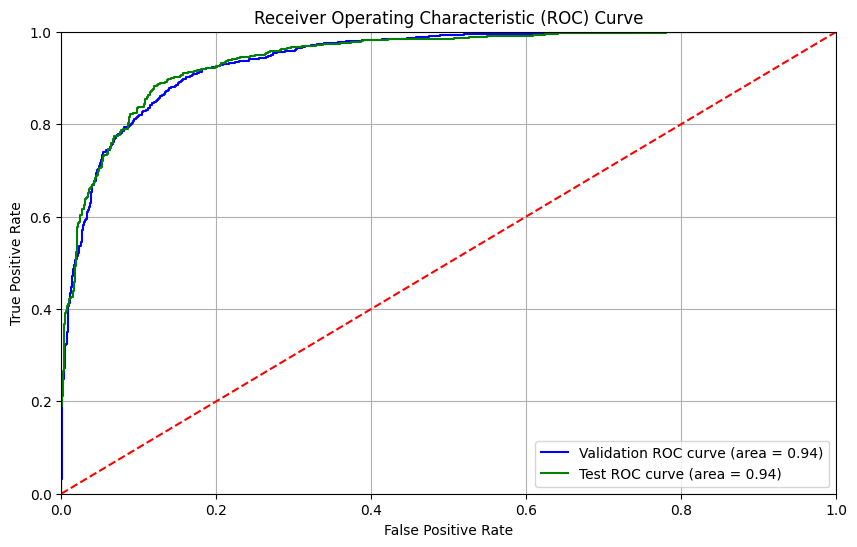

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming val_probs contains the predicted probabilities for the positive class from the validation set
# and val_labels contains the true labels for the validation set.
val_probs = val_probs[:, 1]  # Replace with your actual validation probabilities
val_labels = val_labels  # True labels for validation

# Assuming test_probs contains the predicted probabilities for the positive class from the test set
# and test_labels contains the true labels for the test set.
test_probs = test_probs[:, 1]  # Replace with your actual test probabilities
test_labels = test_labels  # True labels for test

# Compute ROC curve and AUC for validation set
fpr_val, tpr_val, _ = roc_curve(val_labels, val_probs)
roc_auc_val = auc(fpr_val, tpr_val)

# Compute ROC curve and AUC for test set
fpr_test, tpr_test, _ = roc_curve(test_labels, test_probs)
roc_auc_test = auc(fpr_test, tpr_test)

# Plotting both ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', label='Validation ROC curve (area = {:.2f})'.format(roc_auc_val))
plt.plot(fpr_test, tpr_test, color='green', label='Test ROC curve (area = {:.2f})'.format(roc_auc_test))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


### Validation-log-loss,Matthews Correlation Coefficient (MCC), Cohen's Kappa Score,Brier Score

In [ ]:
import tensorflow as tf
from sklearn.metrics import log_loss, matthews_corrcoef, cohen_kappa_score, brier_score_loss

# Validation Metrics
val_loss = log_loss(val_labels, val_probs)  # Assuming val_probs is 1D
val_mcc = matthews_corrcoef(val_labels, val_preds)
val_kappa = cohen_kappa_score(val_labels, val_preds)
val_brier = brier_score_loss(val_labels, val_probs)  # Use val_probs directly

print(f"Validation Log Loss: {val_loss:.4f}")
print(f"Validation MCC: {val_mcc:.4f}")
print(f"Validation Cohen's Kappa Score: {val_kappa:.4f}")
print(f"Validation Brier Score: {val_brier:.4f}")

# Test Metrics
test_loss = log_loss(test_labels, test_probs)  # Assuming test_probs is 1D
test_mcc = matthews_corrcoef(test_labels, test_preds)
test_kappa = cohen_kappa_score(test_labels, test_preds)
test_brier = brier_score_loss(test_labels, test_probs)  # Use test_probs directly

print(f"Test Log Loss: {test_loss:.4f}")
print(f"Test MCC: {test_mcc:.4f}")
print(f"Test Cohen's Kappa Score: {test_kappa:.4f}")
print(f"Test Brier Score: {test_brier:.4f}")


Validation Log Loss: 0.3177
Validation MCC: 0.7275
Validation Cohen's Kappa Score: 0.7271
Validation Brier Score: 0.0978
Test Log Loss: 0.3058
Test MCC: 0.7608
Test Cohen's Kappa Score: 0.7608
Test Brier Score: 0.0928


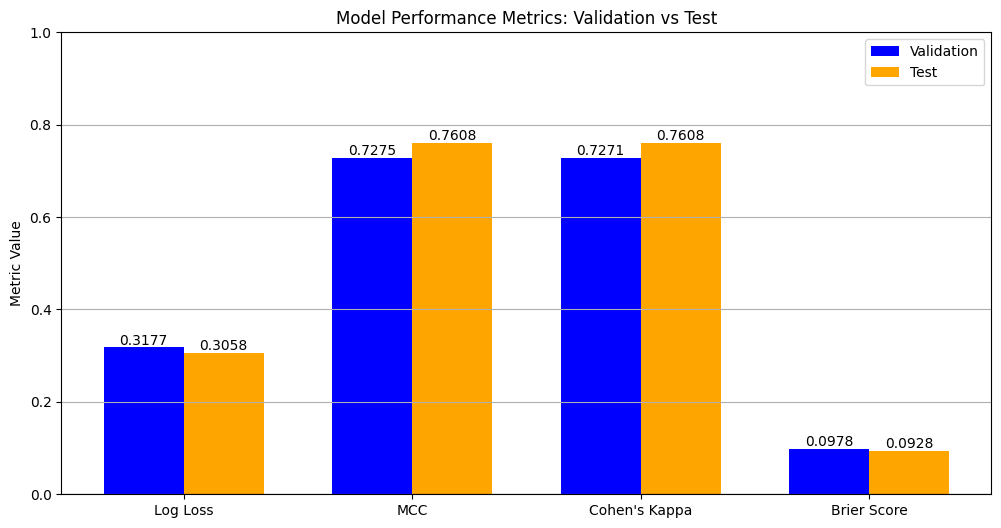

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define metrics and their values for validation and test sets
metrics = ['Log Loss', 'MCC', "Cohen's Kappa", 'Brier Score']

# Replace these with your actual computed metric values for validation and test
val_values = [val_loss, val_mcc, val_kappa, val_brier]  # Validation metrics
test_values = [test_loss, test_mcc, test_kappa, test_brier]  # Test metrics

# Set bar width
bar_width = 0.35

# Create bar plot
x = np.arange(len(metrics))  # the label locations

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, val_values, bar_width, label='Validation', color='blue')
bars2 = plt.bar(x + bar_width/2, test_values, bar_width, label='Test', color='orange')

# Add labels and title
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics: Validation vs Test')
plt.xticks(x, metrics)  # Set x-ticks to metrics names
plt.legend()  # Show legend

# Show value on top of each bar
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Adjust y-axis limit if necessary
plt.axhline(0, color='black', linewidth=0.8)  # Optional: horizontal line at y=0
plt.grid(axis='y')  # Add gridlines for better readability
plt.show()


# distilbert model

In [ ]:
from transformers import DistilBertTokenizer, TFDistilBertModel
# Load DistilBERT tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distil_bert = TFDistilBertModel.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [ ]:
# max_length = max(len(text) for text in df['cleaned_headlines'])
# max_length

In [ ]:
# train_encodings = tokenizer(train_texts.tolist(), padding=True, truncation=True, max_length=max_length)
# # train_encodings = tokenizer(X_train.tolist(), padding=True, truncation=True, max_length=max_length)
# train_encodings
train_encodings = tokenizer(train_texts.tolist(), truncation=True, padding=True, max_length=512)
# test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(val_texts.tolist(), padding=True, truncation=True, max_length=512)
train_encodings

{'input_ids': [[101, 2274, 10539, 22054, 2000, 7861, 9869, 2023, 5353, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1999, 1037, 13576, 2735, 1997, 2824, 2728, 26774, 7283, 4150, 8081, 4383, 2006, 2383, 2010, 2564, 13014, 7332, 2912, 8398, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 1996, 1057, 1055, 4610, 3544, 2000, 2022, 20324, 2005, 13857, 8112, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2047, 3439, 3350, 6083, 2087, 17992, 7434, 2067, 2188, 2000, 8439, 2034, 15060, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2637, 1055, 1999, 27753, 14505, 2007, 9698, 11338, 4783, 2389, 14730, 1999, 6918, 4827, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 10996, 3899, 6552, 2085, 2330, 2005, 2449, 2458, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 3439, 8264, 5060, 2000,

In [ ]:

# test_encodings = tokenizer(X_test.tolist(), padding=True, truncation=True, max_length=max_length)

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), train_labels))
val_dataset= tf.data.Dataset.from_tensor_slices((dict(val_encodings), val_labels))
# train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train))
# test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test))
train_dataset

<_TensorSliceDataset element_spec=({'input_ids': TensorSpec(shape=(38,), dtype=tf.int32, name=None), 'attention_mask': TensorSpec(shape=(38,), dtype=tf.int32, name=None)}, TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
# max_length=130

In [ ]:


# Define input layers
input_ids = tf.keras.Input(shape=(None,), dtype=tf.int32, name='input_ids')
attention_mask = tf.keras.Input(shape=(None,), dtype=tf.int32, name='attention_mask')

# Get the hidden states from DistilBERT backbone
hidden_states = distil_bert(input_ids, attention_mask=attention_mask).last_hidden_state

# Extract the [CLS] token representation (i.e., the first token's hidden state)
cls_token = hidden_states[:, 0, :]

# Custom dense and dropout layers
pooled_dense = tf.keras.layers.Dense(768, activation='relu', name='pooled_dense')(cls_token)
output_dropout = tf.keras.layers.Dropout(0.1, name='output_dropout')(pooled_dense)
logits = tf.keras.layers.Dense(2, name='logits')(output_dropout)

# Define the complete model
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=logits)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, epsilon=1e-08)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, None)]               0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, None)]               0         []                            
 )                                                                                                
                                                                                                  
 tf_distil_bert_model (TFDi  TFBaseModelOutput(last_hid   6636288   ['input_ids[0][0]',           
 stilBertModel)              den_state=(None, None, 768   0          'attention_mask[0][0]']      
                             ),                                                               

In [ ]:
# optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
# loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [ ]:
# test_encodings = tokenizer(
#     X_test.tolist(),
#     padding=True,
#     truncation=True,
#     max_length=max_length  # Use the correct max_length here
# )

In [ ]:


# Early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
history = model.fit(
    train_dataset.shuffle(1000).batch(16),
    epochs=4,
    batch_size=16,
    validation_data = val_dataset.shuffle(1000).batch(16),
    callbacks=[early_stopping]
)

Epoch 1/4
440/440 [==============================] - 65s 93ms/step - loss: 0.3813 - accuracy: 0.8259 - val_loss: 0.3201 - val_accuracy: 0.8681
Epoch 2/4
440/440 [==============================] - 37s 84ms/step - loss: 0.1332 - accuracy: 0.9482 - val_loss: 0.3733 - val_accuracy: 0.8763
Epoch 3/4
440/440 [==============================] - 37s 83ms/step - loss: 0.0510 - accuracy: 0.9821 - val_loss: 0.4930 - val_accuracy: 0.8703
Epoch 4/4
440/440 [==============================] - 36s 83ms/step - loss: 0.0269 - accuracy: 0.9913 - val_loss: 0.6285 - val_accuracy: 0.8717


In [ ]:
# model.summary()

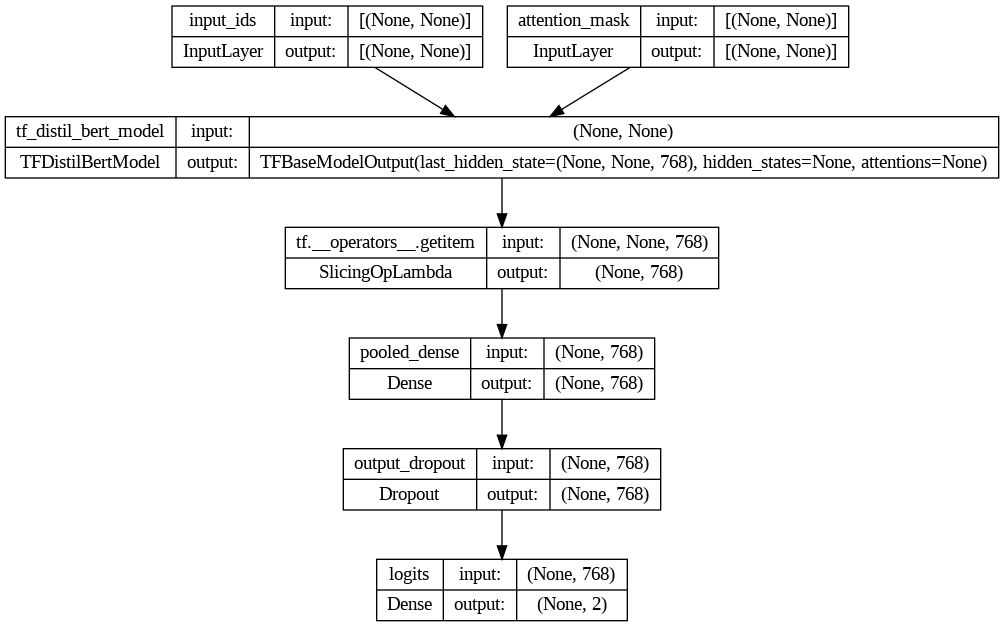

In [ ]:
from tensorflow import keras
keras.utils.plot_model(model, to_file='Distilbert model.png', show_shapes=True)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
# Make predictions and evaluate
val_preds = model.predict(val_dataset.batch(16))
val_preds = tf.argmax(val_preds, axis=1).numpy()   # Get predicted class labels
print("Validation Classification Report:")
print(classification_report(val_labels, val_preds))

# Tokenize and prepare test set
test_encodings = tokenizer(test_texts.to_list(), truncation=True, padding=True, max_length=512)
test_dataset = tf.data.Dataset.from_tensor_slices((
    dict(test_encodings),
    test_labels
))

# Evaluate on test set
test_preds = model.predict(test_dataset.batch(16))
test_preds = tf.argmax(test_preds, axis=1).numpy()  # Get predicted class labels
print("Test Classification Report:")
print(classification_report(test_labels, test_preds))

# Calculate and print accuracy
val_accuracy = accuracy_score(val_labels, val_preds)
test_accuracy = accuracy_score(test_labels, test_preds)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


138/138 [==============================] - 6s 33ms/step
Validation Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1077
           1       0.89      0.84      0.87      1121

    accuracy                           0.87      2198
   macro avg       0.87      0.87      0.87      2198
weighted avg       0.87      0.87      0.87      2198

110/110 [==============================] - 4s 26ms/step
Test Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       874
           1       0.89      0.84      0.87       884

    accuracy                           0.87      1758
   macro avg       0.87      0.87      0.87      1758
weighted avg       0.87      0.87      0.87      1758

Validation Accuracy: 0.8681
Test Accuracy: 0.8692


In [ ]:
# y_probs = model.predict(test_dataset.batch(16))
# y_pred = np.argmax(y_probs, axis=1)

In [ ]:

# model_evaluation_history = model.evaluate(test_dataset.batch(16))

# print(model_evaluation_history)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

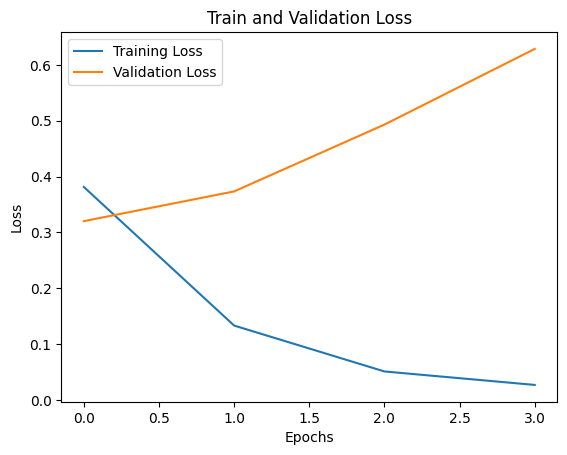

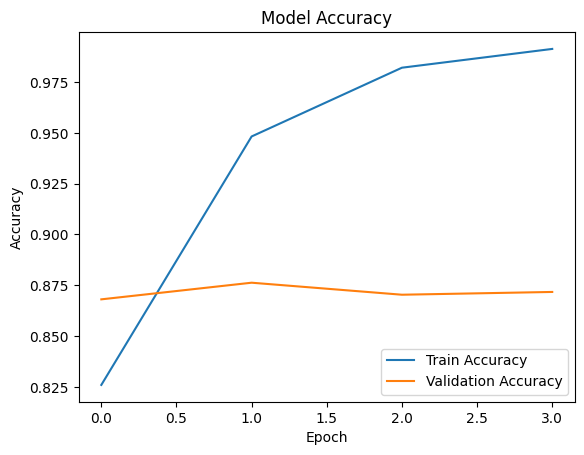

In [ ]:
# Assuming history contains the training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Train and Validation Loss")
plt.legend()  # This will show the legend based on the labels specified above
plt.show()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

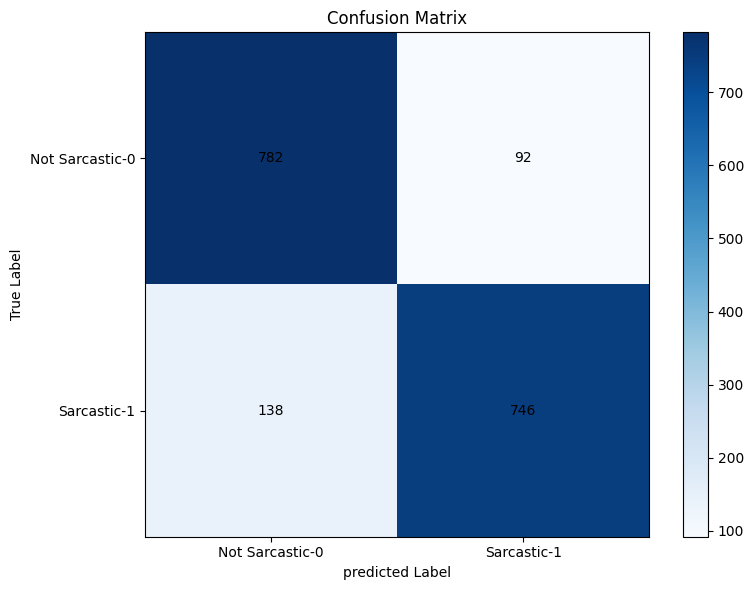

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming 'test_labels' and 'test_preds' are your true and predicted labels for the test set
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])
plt.yticks(tick_marks, ['Not Sarcastic-0', 'Sarcastic-1'])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.xlabel("predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(8,6))
# plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
# plt.title("Confusion Matrix")
# plt.colorbar()
# tick_marks = np.arange(2)
# plt.xticks(tick_marks, ['Nor Sarcastic', 'Sarcastic'])
# plt.yticks(tick_marks, ['Nor Sarcastic', 'Sarcastic'])

# thresh = cm.max() / 2.
# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

# plt.xlabel("predicted Label")
# plt.ylabel("True Label")
# plt.tight_layout()
# plt.show()

In [ ]:
# accuracy = classification_report(y_test, y_pred)
# print(accuracy)

In [ ]:
# # test_preds = model.predict(test_texts)
# # Create a DataFrame with true and predicted labels
# predictions_df = pd.DataFrame({'True_Label': y_test, 'Predicted_Label': y_pred , 'Text': X_test})

# # Display the table
# display(predictions_df[:50])
# Create a DataFrame with true and predicted labels
predictions_df = pd.DataFrame({'True_Label': test_labels, 'Predicted_Label': test_preds, 'Text': test_texts})

# Display the table
display(predictions_df[:50])

,True_Label,Predicted_Label,Text
5708,0,0,this job at netflix is an instagrammer s dream
512,1,1,nasa completely forgot probe was returning today
6759,0,1,the cat observes an unexpected visitor at the ...
4595,0,0,effective pr on a start up budget
10164,1,1,report u s exported billion tons of crude web ...
9513,1,1,family graciously invites cars inside the hous...
5924,0,0,monday s morning email what the global cyberat...
8372,0,0,fishermen hook massive great whites off carolinas
4499,0,0,bangladesh bloggers fear deadly backlash won t...
1725,0,1,a man attempted to eliminate a spider with a l...


### validation- ROC-AUC Cruve

In [ ]:
# Validation dataset
val_probs = model.predict(val_dataset.batch(16))  # Validation predictions as logits
val_probs = tf.nn.softmax(val_probs).numpy()  # Convert logits to probabilities using softmax
val_preds = tf.argmax(val_probs, axis=1).numpy()  # Convert probabilities to class predictions
# Test dataset
test_probs = model.predict(test_dataset.batch(16))  # Test predictions as logits
test_probs = tf.nn.softmax(test_probs).numpy()  # Convert logits to probabilities using softmax
test_preds = tf.argmax(test_probs, axis=1).numpy()  # Convert probabilities to class predictions

110/110 [==============================] - 3s 29ms/step


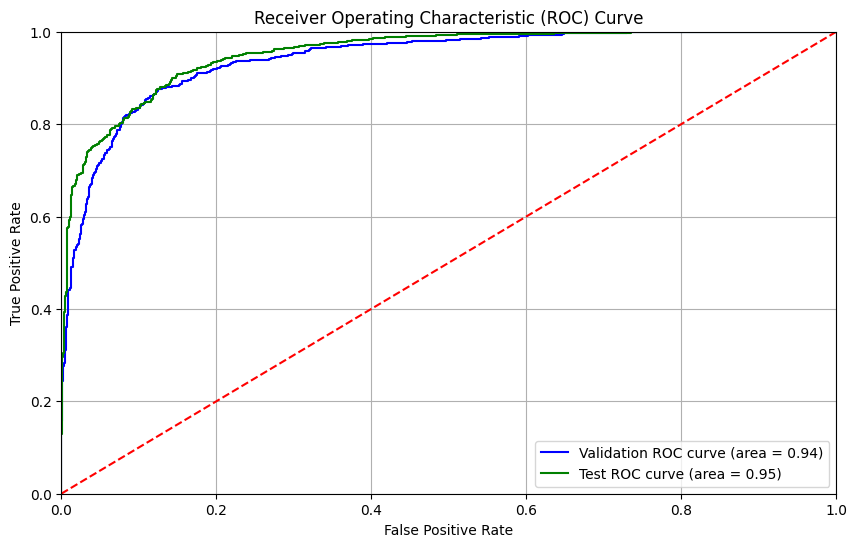

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming val_probs contains the predicted probabilities for the positive class from the validation set
# and val_labels contains the true labels for the validation set.
val_probs = val_probs[:, 1]  # Replace with your actual validation probabilities
val_labels = val_labels  # True labels for validation

# Assuming test_probs contains the predicted probabilities for the positive class from the test set
# and test_labels contains the true labels for the test set.
test_probs = test_probs[:, 1]  # Replace with your actual test probabilities
test_labels = test_labels  # True labels for test

# Compute ROC curve and AUC for validation set
fpr_val, tpr_val, _ = roc_curve(val_labels, val_probs)
roc_auc_val = auc(fpr_val, tpr_val)

# Compute ROC curve and AUC for test set
fpr_test, tpr_test, _ = roc_curve(test_labels, test_probs)
roc_auc_test = auc(fpr_test, tpr_test)

# Plotting both ROC curves
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', label='Validation ROC curve (area = {:.2f})'.format(roc_auc_val))
plt.plot(fpr_test, tpr_test, color='green', label='Test ROC curve (area = {:.2f})'.format(roc_auc_test))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()


### Validation-log-loss,Matthews Correlation Coefficient (MCC), Cohen's Kappa Score,Brier Score

In [ ]:
import tensorflow as tf
from sklearn.metrics import log_loss, matthews_corrcoef, cohen_kappa_score, brier_score_loss

# Validation Metrics
val_loss = log_loss(val_labels, val_probs)  # Assuming val_probs is 1D
val_mcc = matthews_corrcoef(val_labels, val_preds)
val_kappa = cohen_kappa_score(val_labels, val_preds)
val_brier = brier_score_loss(val_labels, val_probs)  # Use val_probs directly

print(f"Validation Log Loss: {val_loss:.4f}")
print(f"Validation MCC: {val_mcc:.4f}")
print(f"Validation Cohen's Kappa Score: {val_kappa:.4f}")
print(f"Validation Brier Score: {val_brier:.4f}")

# Test Metrics
test_loss = log_loss(test_labels, test_probs)  # Assuming test_probs is 1D
test_mcc = matthews_corrcoef(test_labels, test_preds)
test_kappa = cohen_kappa_score(test_labels, test_preds)
test_brier = brier_score_loss(test_labels, test_probs)  # Use test_probs directly

print(f"Test Log Loss: {test_loss:.4f}")
print(f"Test MCC: {test_mcc:.4f}")
print(f"Test Cohen's Kappa Score: {test_kappa:.4f}")
print(f"Test Brier Score: {test_brier:.4f}")


Validation Log Loss: 0.3201
Validation MCC: 0.7376
Validation Cohen's Kappa Score: 0.7363
Validation Brier Score: 0.0978
Test Log Loss: 0.2898
Test MCC: 0.7394
Test Cohen's Kappa Score: 0.7384
Test Brier Score: 0.0893


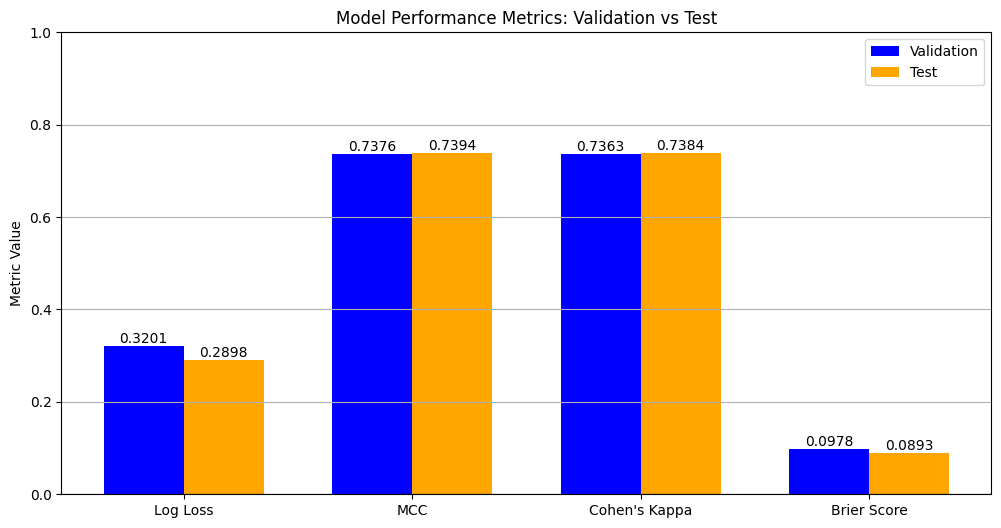

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define metrics and their values for validation and test sets
metrics = ['Log Loss', 'MCC', "Cohen's Kappa", 'Brier Score']

# Replace these with your actual computed metric values for validation and test
val_values = [val_loss, val_mcc, val_kappa, val_brier]  # Validation metrics
test_values = [test_loss, test_mcc, test_kappa, test_brier]  # Test metrics

# Set bar width
bar_width = 0.35

# Create bar plot
x = np.arange(len(metrics))  # the label locations

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - bar_width/2, val_values, bar_width, label='Validation', color='blue')
bars2 = plt.bar(x + bar_width/2, test_values, bar_width, label='Test', color='orange')

# Add labels and title
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics: Validation vs Test')
plt.xticks(x, metrics)  # Set x-ticks to metrics names
plt.legend()  # Show legend

# Show value on top of each bar
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), ha='center', va='bottom')

plt.ylim(0, 1)  # Adjust y-axis limit if necessary
plt.axhline(0, color='black', linewidth=0.8)  # Optional: horizontal line at y=0
plt.grid(axis='y')  # Add gridlines for better readability
plt.show()
